In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

mental_health = pd.read_csv("data/social_media_mental_health.csv")

mental_health.head()

,User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity
0,U-b23639d2,18,Male,Hyper-Connected,Twitter/X,8.50,Gaming,Active,0,0,3.9,9,Mild,5,Mild
1,U-e7778765,20,Male,Digital Minimalist,TikTok,0.50,Gaming,Active,0,0,5.5,0,Minimal,8,Mild
2,U-76749892,18,Female,Digital Minimalist,Snapchat,0.91,Gaming,Active,0,0,8.9,1,Minimal,3,None-Minimal
3,U-dcbbd7f9,18,Female,Hyper-Connected,Snapchat,7.43,Gaming,Active,1,0,6.2,13,Moderate,0,None-Minimal
4,U-9e1ba278,18,Male,Hyper-Connected,LinkedIn,4.94,Entertainment/Comedy,Active,1,0,5.3,13,Moderate,10,Moderate


In [3]:
# looking for null values, understanding dtype

mental_health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    8000 non-null   object 
 1   Age                        8000 non-null   int64  
 2   Gender                     8000 non-null   object 
 3   User_Archetype             8000 non-null   object 
 4   Primary_Platform           8000 non-null   object 
 5   Daily_Screen_Time_Hours    8000 non-null   float64
 6   Dominant_Content_Type      8000 non-null   object 
 7   Activity_Type              8000 non-null   object 
 8   Late_Night_Usage           8000 non-null   int64  
 9   Social_Comparison_Trigger  8000 non-null   int64  
 10  Sleep_Duration_Hours       8000 non-null   float64
 11  GAD_7_Score                8000 non-null   int64  
 12  GAD_7_Severity             8000 non-null   object 
 13  PHQ_9_Score                8000 non-null   int64

In [4]:
# looking for duplicates

mental_health['User_ID'].duplicated().sum()

np.int64(0)

In [5]:
# we can drop this column - it is not actual for us.

mental_health.drop('User_ID', axis=1, inplace=True)

In [6]:
mental_health.describe()

,Age,Daily_Screen_Time_Hours,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,PHQ_9_Score
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,19.057875,4.277210,0.379375,0.103125,5.803237,7.354250,5.380125
std,1.117892,2.310486,0.485262,0.304141,1.344054,4.633108,4.816641
min,18.000000,0.500000,0.000000,0.000000,3.000000,0.000000,0.000000
25%,18.000000,2.420000,0.000000,0.000000,4.800000,4.000000,1.000000
50%,19.000000,4.270000,0.000000,0.000000,5.800000,7.000000,5.000000
75%,20.000000,6.050000,1.000000,0.000000,6.800000,11.000000,9.000000
max,22.000000,11.310000,1.000000,1.000000,11.600000,21.000000,23.000000


In [7]:
# Prints unique values for each column in order to understand what each columns contains

def get_unique_values(df):
    
    for column in df.columns:
        unique_values = df[column].unique().tolist()
        print(f"Column: **{column}**")
        print(f"Values ({len(unique_values)}): {unique_values}")
        print("-" * 30)

get_unique_values(mental_health)

Column: **Age**
Values (5): [18, 20, 21, 19, 22]
------------------------------
Column: **Gender**
Values (2): ['Male', 'Female']
------------------------------
Column: **User_Archetype**
Values (4): ['Hyper-Connected', 'Digital Minimalist', 'Passive Scroller', 'Average User']
------------------------------
Column: **Primary_Platform**
Values (7): ['Twitter/X', 'TikTok', 'Snapchat', 'LinkedIn', 'YouTube', 'Facebook', 'Instagram']
------------------------------
Column: **Daily_Screen_Time_Hours**
Values (915): [8.5, 0.5, 0.91, 7.43, 4.94, 0.56, 6.57, 7.18, 3.41, 1.97, 7.59, 4.18, 1.19, 5.17, 3.38, 3.19, 1.67, 6.3, 3.11, 3.42, 7.96, 7.38, 6.88, 4.63, 6.48, 6.02, 3.58, 0.8, 0.61, 6.1, 4.53, 0.95, 2.44, 0.93, 7.53, 1.15, 5.69, 4.27, 9.35, 3.16, 1.88, 2.39, 4.5, 1.3, 2.24, 3.76, 2.42, 4.88, 8.7, 6.42, 6.83, 4.37, 5.7, 1.36, 6.45, 1.56, 2.84, 8.57, 2.51, 3.53, 5.61, 9.36, 5.43, 6.56, 1.5, 2.64, 4.74, 5.44, 3.67, 6.33, 2.72, 6.27, 8.13, 5.42, 1.55, 1.51, 7.86, 5.72, 8.1, 9.31, 7.12, 3.37, 2.7

In [8]:
# function to detect which column is numeric, which categorical, which binary (for further analysis):

def inspect_columns(df):
    
    numeric_cols = []
    binary_cols = []
    categorical_cols = []

    for col in df.columns:
        unique_vals = sorted(df[col].unique())
        
        if set(unique_vals) == {0, 1}:
            binary_cols.append(col)
        
        elif pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)
            
        else:
            categorical_cols.append(col)

    print(f"{'='*30}")
    print(f"DATASET INSPECTION")
    print(f"{'='*30}")
    print(f"BINARY (0/1): {binary_cols if binary_cols else 'None'}")
    print(f"NUMERIC: {numeric_cols if numeric_cols else 'None'}")
    print(f"CATEGORICAL: {categorical_cols if categorical_cols else 'None'}")
    print(f"{'='*30}")

inspect_columns(mental_health)

DATASET INSPECTION
BINARY (0/1): ['Late_Night_Usage', 'Social_Comparison_Trigger']
NUMERIC: ['Age', 'Daily_Screen_Time_Hours', 'Sleep_Duration_Hours', 'GAD_7_Score', 'PHQ_9_Score']
CATEGORICAL: ['Gender', 'User_Archetype', 'Primary_Platform', 'Dominant_Content_Type', 'Activity_Type', 'GAD_7_Severity', 'PHQ_9_Severity']


In [9]:
# creating function in order to understand numerical data's distrubution and outliers.

def numerical_col_plots(df, column=None):
    """
    Creates a histogram and boxplot for a specific column or all numerical columns.
    """
    if column:
        numeric_cols = [column]
    else:
        numeric_cols = df.select_dtypes(include=['number']).columns
    
    for col in numeric_cols:
        fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(15, 5))
        
        median_val = df[col].median()
        mean_val = df[col].mean()

        # --- LEFT: Histogram (Distribution) ---
        sns.histplot(df[col], kde=True, ax=ax_hist, color='skyblue', alpha=0.7)
        ax_hist.axvline(median_val, color='red', linestyle='--', linewidth=2, label=f"Median: {median_val:.2f}")
        ax_hist.axvline(mean_val, color='green', linestyle='-', linewidth=2, label=f"Mean: {mean_val:.2f}")
        ax_hist.set_title(f'{col} - Distribution (Histogram)')
        ax_hist.legend() 

        # --- Right: Boxplot (Outliers & Quartiles) ---
        sns.boxplot(x=df[col], ax=ax_box, color='plum', width=0.5)
        ax_box.axvline(median_val, color='red', linestyle='--', linewidth=2)
        ax_box.axvline(mean_val, color='green', linestyle='-', linewidth=2)
        ax_box.set_title(f'{col} - Outliers (Boxplot)')

        plt.suptitle(f'Distribution and Outliers Analysis for "{col}"', fontsize=14, fontweight='bold')
        plt.tight_layout() 
        plt.show()

# For all numerical columns:
# numerical_col_plots(mental_health)

# For each numerical column:
# numerical_col_plots(mental_health, column='PHQ_9_Score')

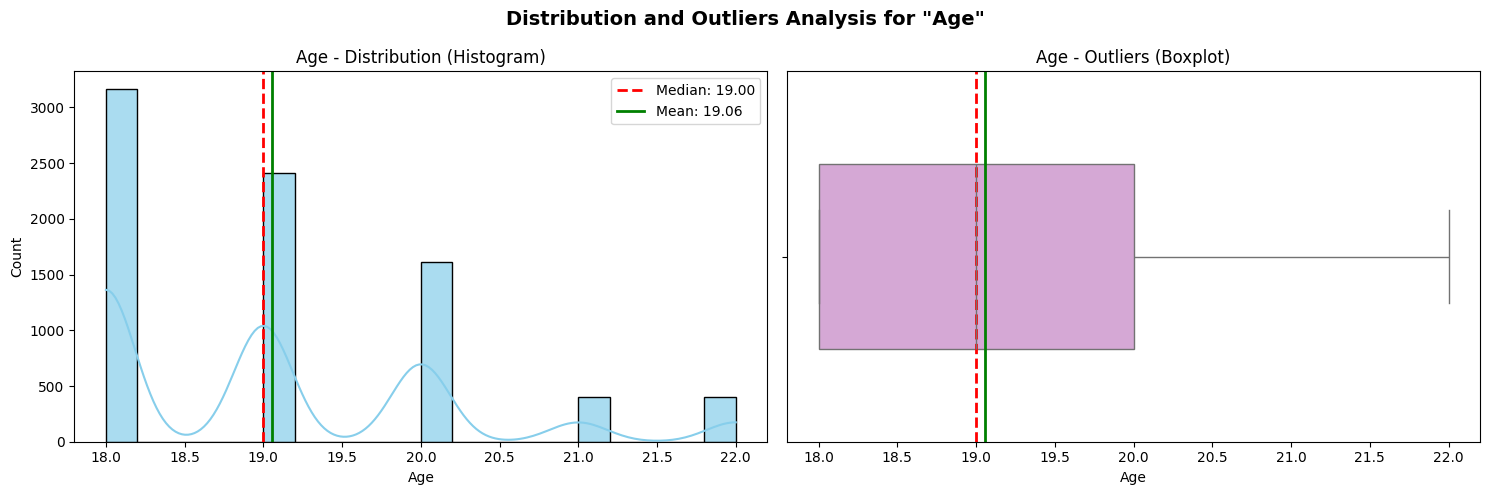

In [10]:
numerical_col_plots(mental_health, column='Age')

According to the histogram, we can see that the data reflects a very small part of the population, it can be said that this is young people from 18 to 22 years old. The average and median are about 19 (majority of respondents are about 19 years old).  
We cannot apply insights to the entire population, because data for all age groups has not been collected.  
The real situation can be distorted if we try to apply the insights to the older age category.

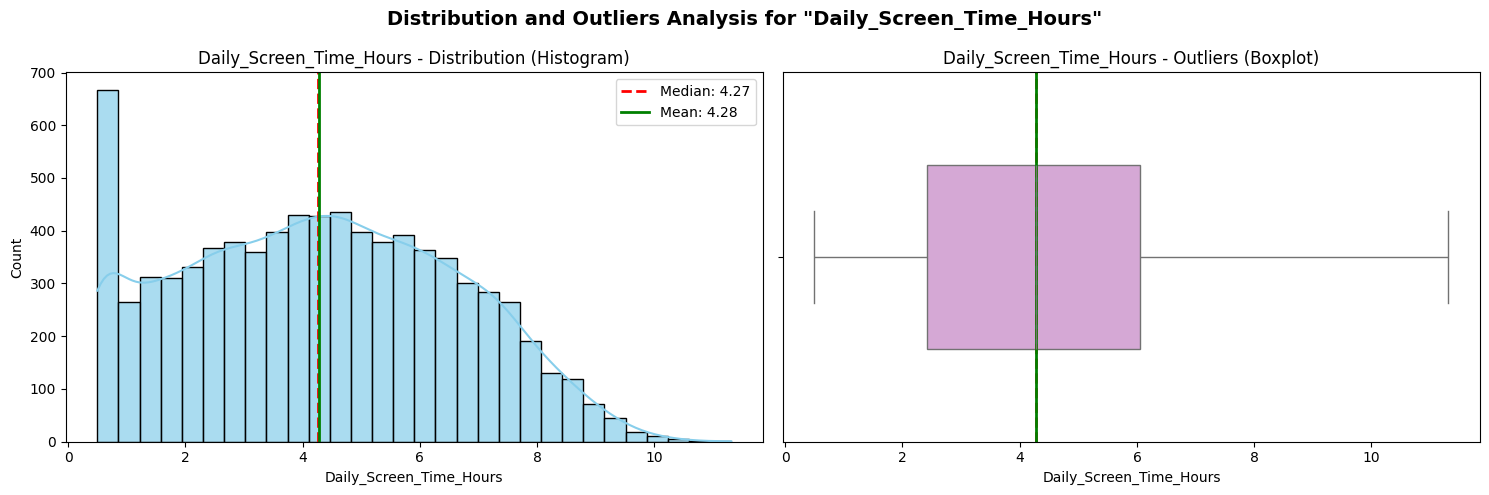

In [11]:
numerical_col_plots(mental_health, column='Daily_Screen_Time_Hours')

When analyzing daily screen time hours, we see that people aged 18-22 spend an average of about 4 hours in front of a screen (median 4.27, mean 4.28). Highest concentration: Most of the subjects (in the 18-22 age group) spend between 3 and 6 hours per day.

Outliers: we see that some individuals reach even 10-11 hours. From a health science perspective, this is a “risk group” characterized by the greatest negative impact on sleep duration and mental health.

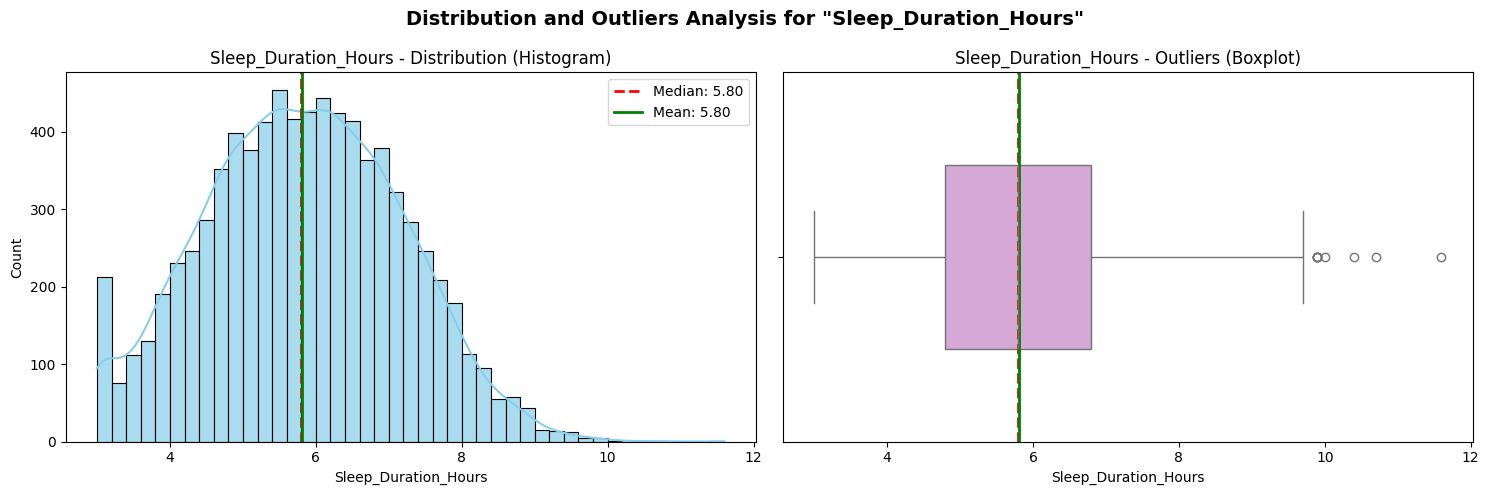

In [12]:
numerical_col_plots(mental_health, column='Sleep_Duration_Hours')

We can see that the data distribution is symmetrical, but the  average sleep is significantly lower than the recommended norm. The mean and median coincide at the 5.80 hours. This signals that the average subject sleeps almost 2 hours less than recommended by health organizations (7–9 hours).

The histogram resembles a bell curve, which means that the 5.8 hour sleep duration is not a random exception, but a mass phenomenon in this sample.

Outliers: the boxplot recorded positive outliers – individuals who sleep 10–12 hours.  

Critical zone for health: there are subjects who sleep less then 4 hours. It is appropriate to compare how sleep duration is related to depression scores and anxiety scores (further in the study).

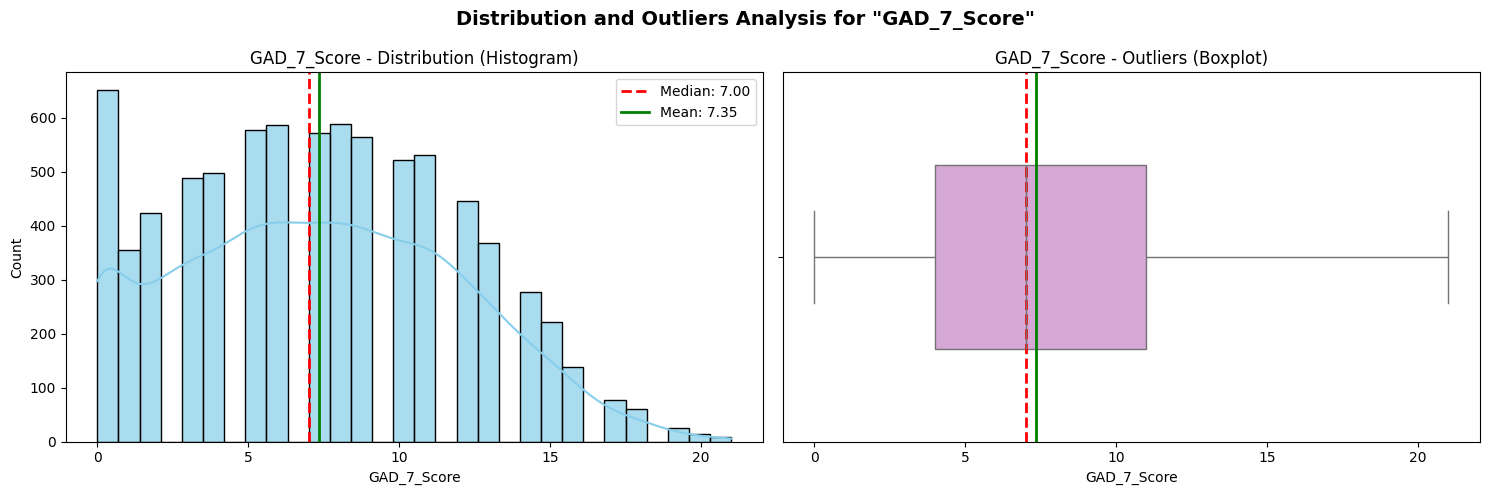

In [13]:
numerical_col_plots(mental_health, column='GAD_7_Score')

GAD-7 (Generalized Anxiety Disorder) scores:

Distribution: Scores range from 0 to over 20. A median of 7.00 indicates that a substantial portion of the participants falls into the "Mild Anxiety" category (5-9 points).

Outliers: The boxplot shows that while most scores are concentrated between 4 and 11, there is a significant tail extending towards severe anxiety (20+).

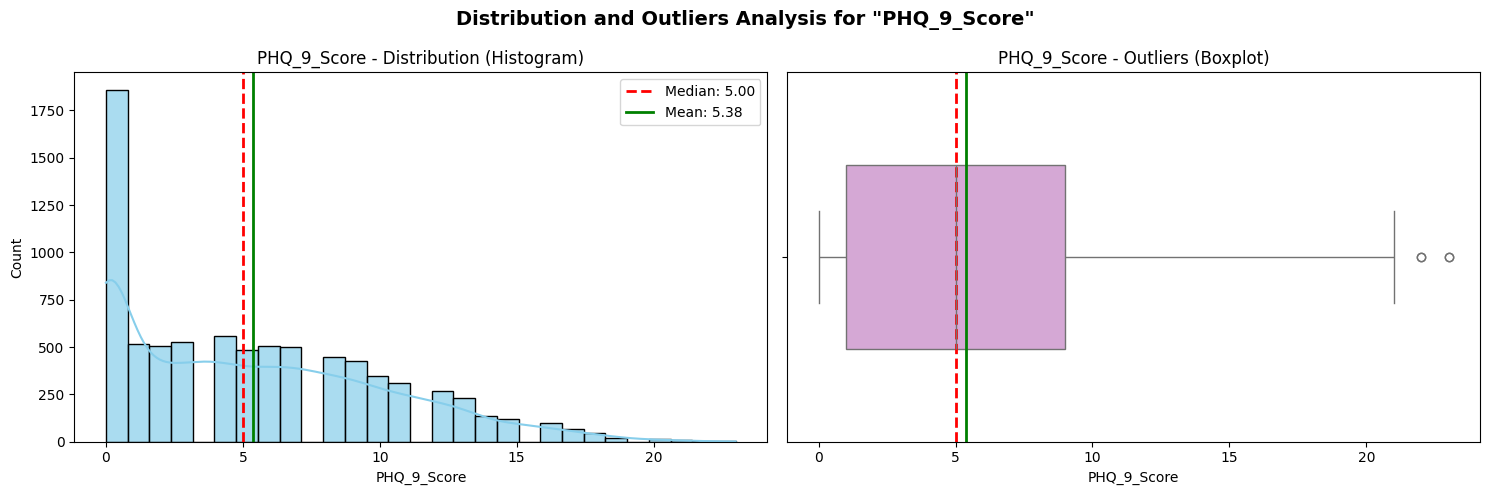

In [14]:
numerical_col_plots(mental_health, column='PHQ_9_Score')

The median score is 5.00, but there is a peak in the histogram: nearly 1,800 individuals have very low scores (0–2). It can be said that there is very mild impact on depression (caused by digital habits).
While many are resilient, there is a steady "tail" of individuals (outliers reaching scores of 20+) who are likely experiencing clinical depression.

It is important to analyse how sleep duration relates to depression and anxiety scores.

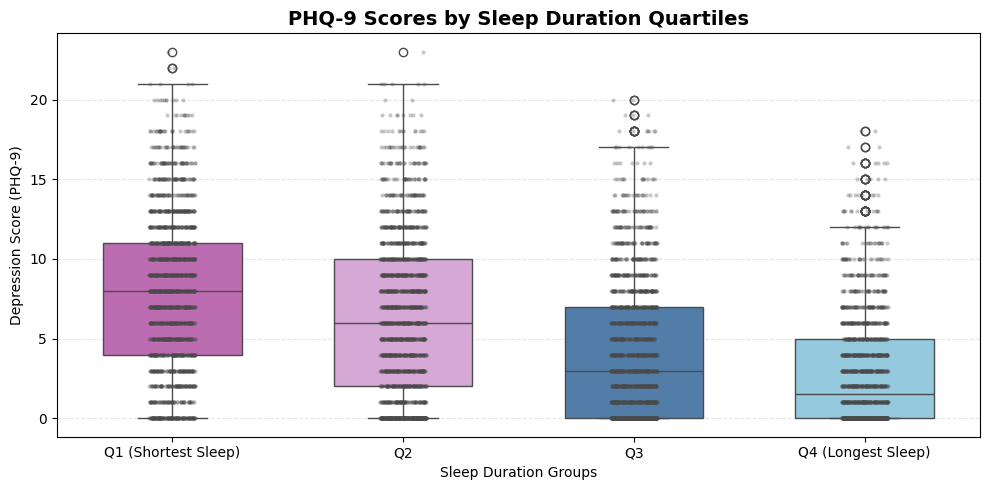

In [15]:
# 1. Preparing Sleep_Duration_Hours Quartiles
mental_health['Sleep_Quartile'] = pd.qcut(mental_health['Sleep_Duration_Hours'], 4, 
                                          labels=['Q1 (Shortest Sleep)', 'Q2', 'Q3', 'Q4 (Longest Sleep)'])

# 2. Create a custom color palette matching main colors in other plots
custom_palette = sns.color_palette(["#C95FBB","plum", "#437DB8", "skyblue"])

plt.figure(figsize=(10, 5))

# 3. Visualize using Boxplot with the new palette
sns.boxplot(data=mental_health, 
            x='Sleep_Quartile', 
            y='PHQ_9_Score', 
            hue='Sleep_Quartile', 
            palette=custom_palette, 
            width=0.6, 
            legend=False)

# 4. Add individual data points (stripplot)
# Using a slightly darker grey for better visibility against the light colors
sns.stripplot(data=mental_health, x='Sleep_Quartile', y='PHQ_9_Score', 
              color='#4A4A4A', size=3, alpha=0.3, jitter=True)

# Formatting
plt.title('PHQ-9 Scores by Sleep Duration Quartiles', fontweight='bold', fontsize=14)
plt.ylabel('Depression Score (PHQ-9)')
plt.xlabel('Sleep Duration Groups')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

We observe the following relationship between sleep duration and depression score: it can be stated that the less a person sleeps (ages of 18-22), the more their depression scores increase, the more severe their depression becomes. And the longer a person sleeps, the less depressed they are.

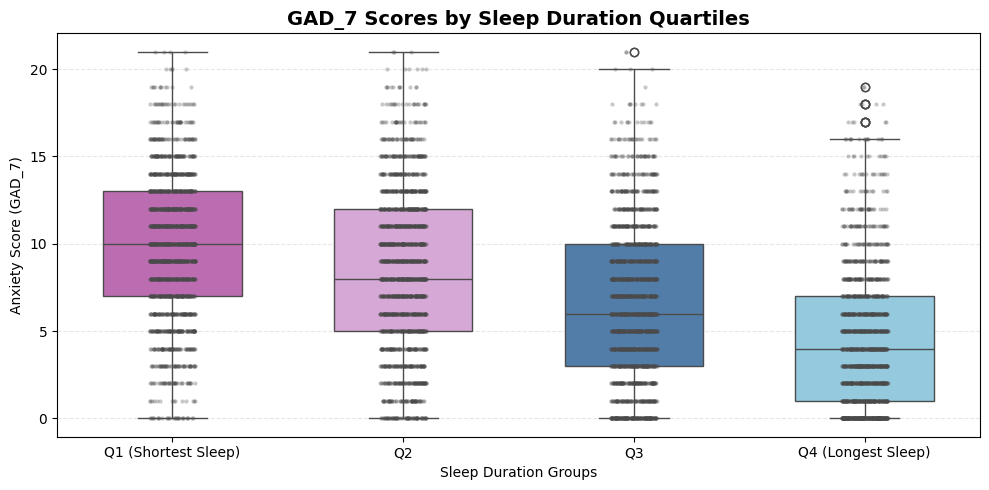

In [16]:
# Comparing Sleep_Quartile by GAD_7_score (anxiety).

plt.figure(figsize=(10, 5))

sns.boxplot(data=mental_health, 
            x='Sleep_Quartile', 
            y='GAD_7_Score', 
            hue='Sleep_Quartile', 
            palette=custom_palette, 
            width=0.6, 
            legend=False)

# 4. Add individual data points (stripplot)
# Using a slightly darker grey for better visibility against the light colors
sns.stripplot(data=mental_health, x='Sleep_Quartile', y='GAD_7_Score', 
              color='#4A4A4A', size=3, alpha=0.3, jitter=True)

# Formatting
plt.title('GAD_7 Scores by Sleep Duration Quartiles', fontweight='bold', fontsize=14)
plt.ylabel('Anxiety Score (GAD_7)')
plt.xlabel('Sleep Duration Groups')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

We see that the sleep duration has a similar relationship with anxiety scores (as with depression scores): the less a person sleeps, the more anxiety they experience.

Prior to constructing the correlation matrix, it is essential to analyze the distribution of categorical variables to identify underlying patterns and tendencies.

In [17]:
# creating function in order to analise categorical data's distribution

def categorical_col_plots(df, column=None, colour='plum'):
    
    if column:
        categorical_cols = [column]
    else:
        categorical_cols = df.select_dtypes(include=['object', 'category']).columns

    for col in categorical_cols:
        counts = df[col].value_counts()
        total = len(df[col])
        
        plt.figure(figsize=(10, 5))
        
        bars = plt.bar(counts.index.astype(str), counts.values, 
                       color=colour, edgecolor='black', alpha=0.8, width=0.6)
        
        for bar in bars:
            height = bar.get_height()
            percentage = (height / total) * 100
            plt.text(bar.get_x() + bar.get_width()/2., height / 2,
            f'{int(height)}\n({percentage:.1f}%)',
            ha='center', va='center', color='white', fontweight='bold', fontsize=9)

        plt.title(f'"{col}" Distribution', fontsize=14, fontweight='bold', pad=15)
        plt.ylabel('Frequency', fontsize=11)
        plt.xlabel(f'{col}', fontsize=11)
        
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.4) # Standartinis tinklelis
        
        plt.tight_layout() 
        plt.show()

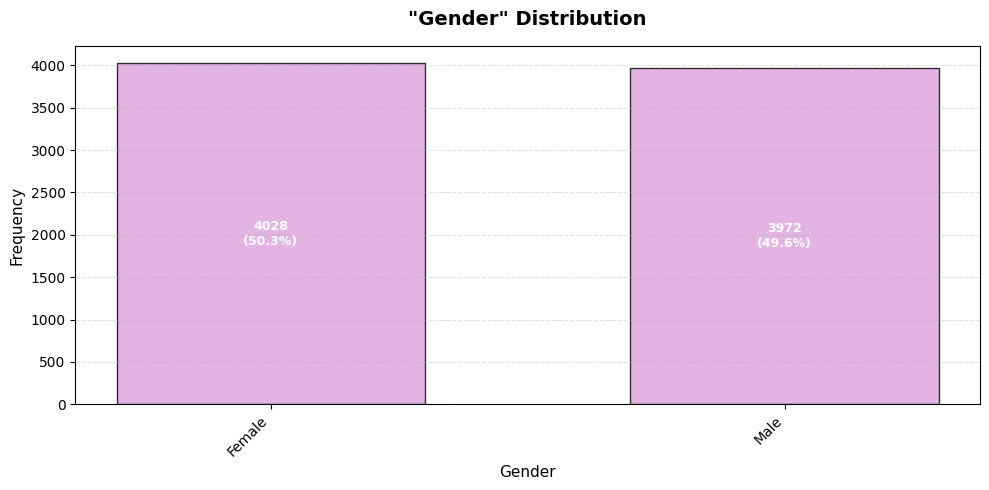

In [18]:
categorical_col_plots(mental_health, column='Gender')

The distribution between male and female participants is nearly equal. This balanced representation ensures that our gender-based analysis is unbiased and suggests that, in this specific dataset, gender may not be a primary determinant of mental health outcomes.

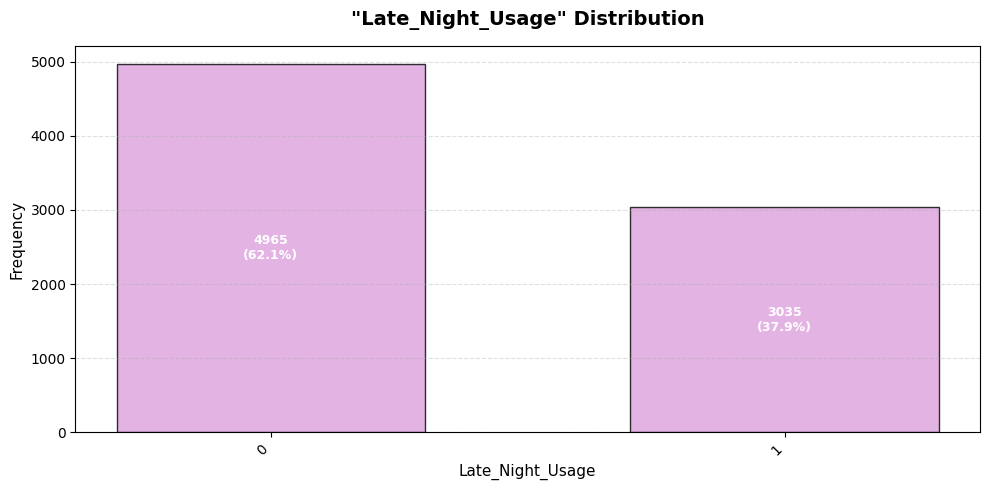

In [19]:
categorical_col_plots(mental_health, column='Late_Night_Usage')

Key Finding: 37.9% of participants are identified as late-night device users. This sub-group will be a primary focus in our correlation analysis to determine its impact on overall sleep quality and mental health stability.

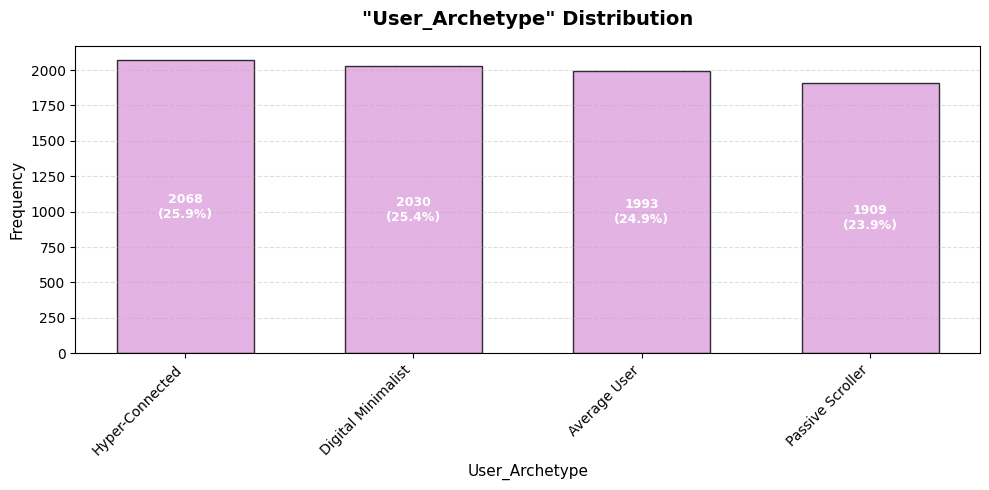

In [20]:
categorical_col_plots(mental_health, column='User_Archetype')

This population is remarkably well-balanced across four distinct digital archetypes, with each category representing approximately 25% of the total sample. This uniform distribution is ideal for comparative analysis, as it minimizes group-size bias.

The 'Hyper-Connected' segment (25.9%) represents our primary high-exposure group, while the 'Digital Minimalist' (25.4%) serves as a functional control group for lifestyle-related mental health outcomes.

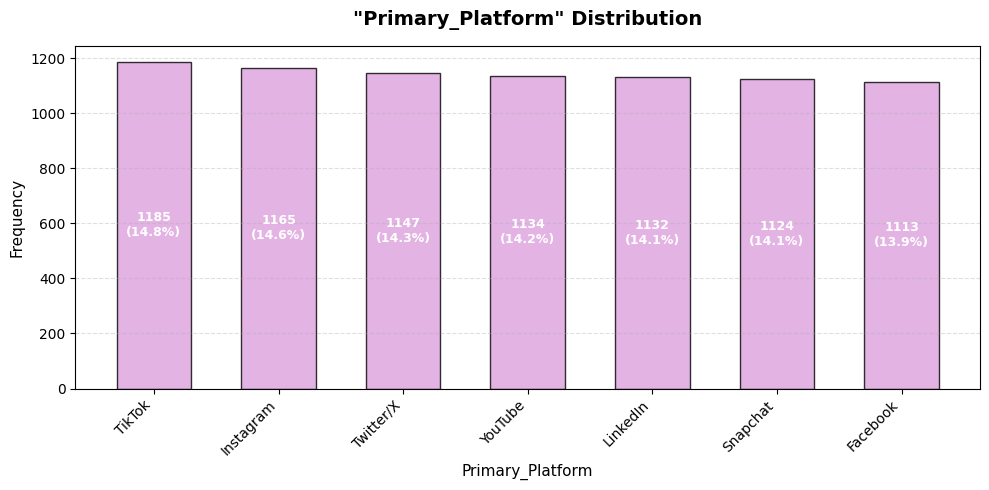

In [21]:
categorical_col_plots(mental_health, column='Primary_Platform')

This chart shows which social media platforms people use the most. The results are very interesting because the usage is almost perfectly equal across all platforms.

Key Points:  
TikTok is the most popular, but only by a tiny bit (14.8%).  
Facebook is the least used, but still holds a strong 13.9%.  
All other platforms (Instagram, YouTube, etc.) are right in the middle, between 14% and 14.6%.

Since the groups are almost the same size (about 1,100 people per platform), I can fairly compare them. For example, I can now check if TikTok users have more anxiety or less sleep than LinkedIn users without the data being biased. This makes my final results much more reliable.

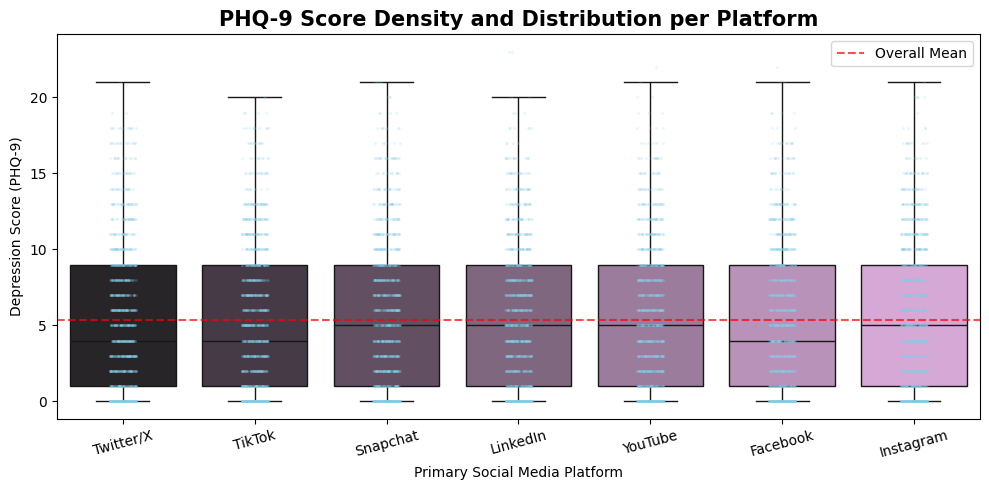

In [22]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=mental_health, 
            x='Primary_Platform', 
            y='PHQ_9_Score', 
            hue='Primary_Platform',
            palette='dark:plum',   
            color = 'plum', 
            fliersize=0, 
            legend=False)

sns.stripplot(data=mental_health, 
              x='Primary_Platform', 
              y='PHQ_9_Score', 
              color='skyblue', 
              size=2, 
              alpha=0.2, 
              jitter=True)


plt.axhline(mental_health['PHQ_9_Score'].mean(), color='red', linestyle='--', alpha=0.7, label='Overall Mean')

plt.title('PHQ-9 Score Density and Distribution per Platform', fontweight='bold', fontsize=15)
plt.ylabel('Depression Score (PHQ-9)')
plt.xlabel('Primary Social Media Platform')
plt.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

When we look at depression scores (PHQ-9) across different platforms, the results are surprisingly similar. Whether a person primarily uses TikTok, Instagram, or LinkedIn, their median mental health scores stay almost the same (around 4-5 points).

This suggests that the specific platform doesn't matter as much as how much time you spend on it or when you use it. For example, a TikTok user and a LinkedIn user have the same risk of high scores. This finding is important because it shows that the problem is likely 'social media use' in general, not one specific app.

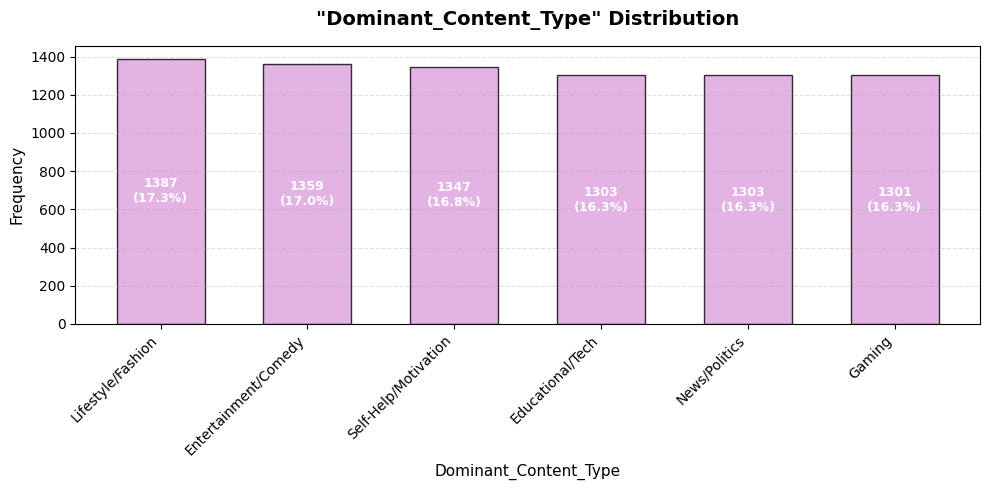

In [23]:
categorical_col_plots(mental_health, column='Dominant_Content_Type')

The data shows that content interests are very diverse and split almost equally.

Lifestyle and Fashion is the most common content type, but only by a small margin (17.3%).  
Gaming, News, and Education are all tied at around 16.3%.  

This balance means that I can compare different groups fairly. For example, I can now investigate if people who watch News/Politics have higher anxiety scores than those who watch Comedy, without worrying that one group is too small to be trusted.

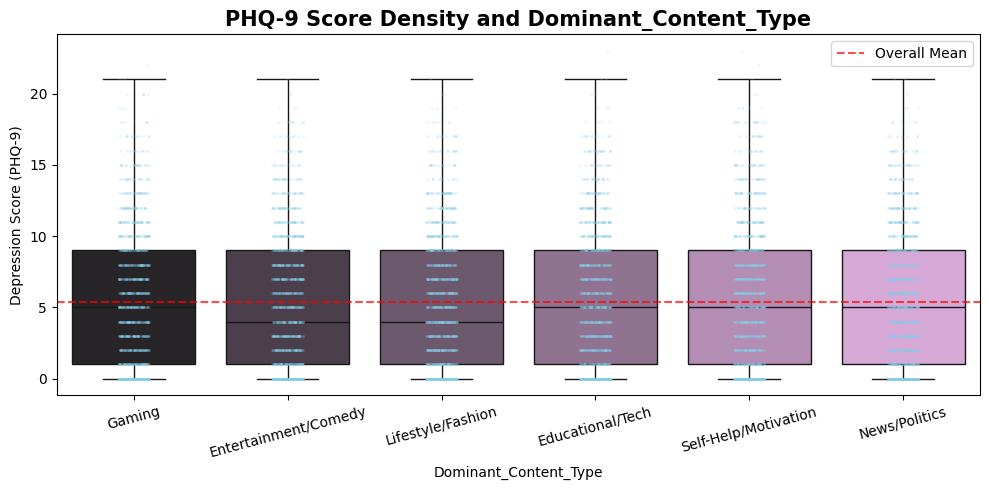

In [24]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=mental_health, 
            x='Dominant_Content_Type', 
            y='PHQ_9_Score', 
            hue='Dominant_Content_Type',
            palette='dark:plum',   
            color = 'plum', 
            fliersize=0, 
            legend=False)

sns.stripplot(data=mental_health, 
              x='Dominant_Content_Type', 
              y='PHQ_9_Score', 
              color='skyblue', 
              size=2, 
              alpha=0.2, 
              jitter=True)


plt.axhline(mental_health['PHQ_9_Score'].mean(), color='red', linestyle='--', alpha=0.7, label='Overall Mean')

plt.title('PHQ-9 Score Density and Dominant_Content_Type', fontweight='bold', fontsize=15)
plt.ylabel('Depression Score (PHQ-9)')
plt.xlabel('Dominant_Content_Type')
plt.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

According to this data, type of content do not affect mental health of these young people. Whether a user watches 'News/Politics', 'Gaming', or 'Comedy', their depression scores (PHQ-9) stay almost the same.

All content types have the same median score of about 4-5 points. This means that what you watch is not as important as how much or when you watch it. Even 'News/Politics', which people often think is stressful, shows the same results as 'Entertainment/Comedy'. This tells us that mental health issues in this group are likely caused by other factors, like sleep deprivation or total screen time, rather than the content itself.

(In correlation matrix this feature should be near zero).

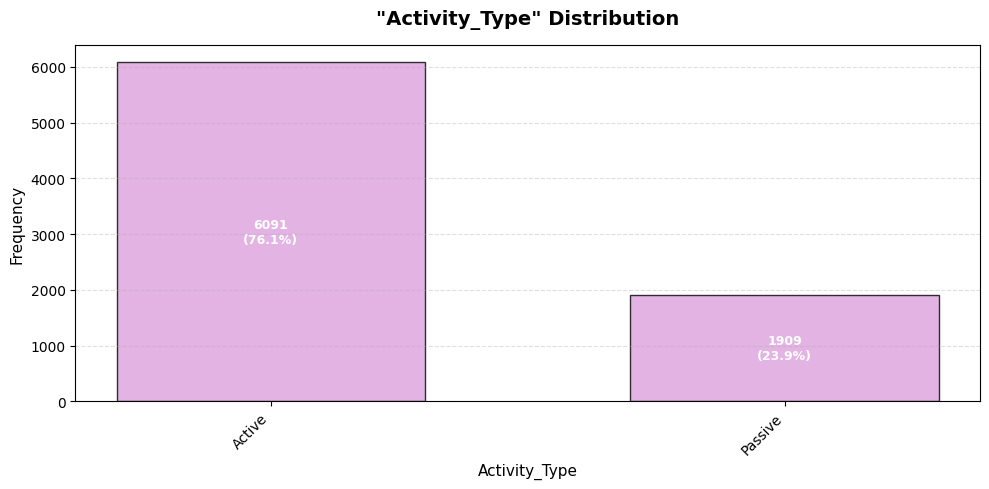

In [25]:
categorical_col_plots(mental_health, column='Activity_Type')

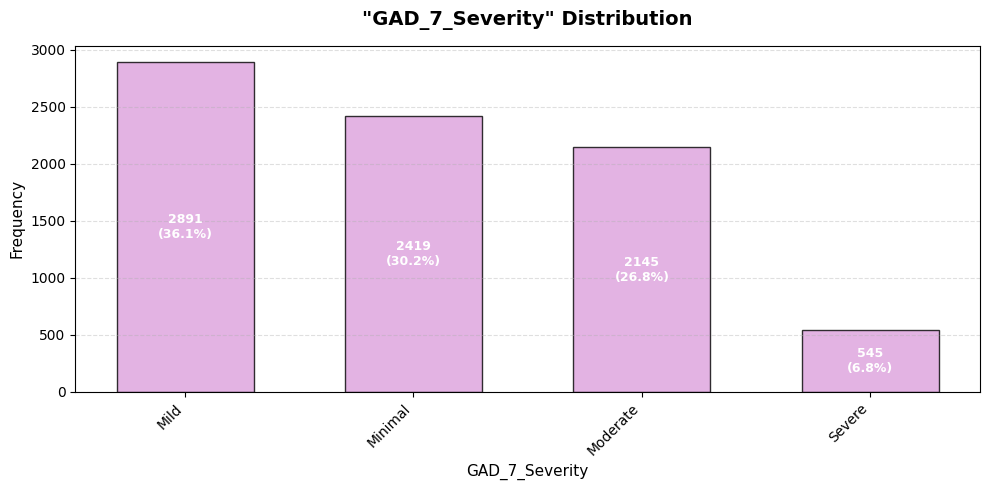

In [26]:
categorical_col_plots(mental_health, column='GAD_7_Severity')

The majority of social media users (aged 18-22) have mild to moderate anxiety (62.9% combined), and 6.8% users have severe anxiety.

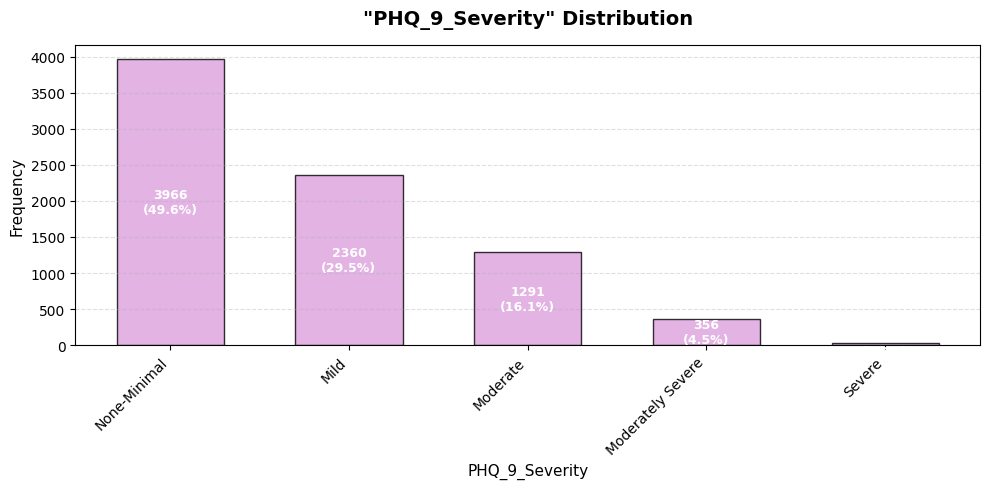

In [27]:
categorical_col_plots(mental_health, column='PHQ_9_Severity')

Meanwhile, the distribution of depression levels is significantly more favorable: 49.6% of social media users report no or very minimal symptoms of depression. Only about 5% of users exhibit a moderatly severe and severe level of depression.

Further I am using a pairplot to visualize the relationships between all numerical variables at once. This helps me quickly identify if there are any clear patterns. 

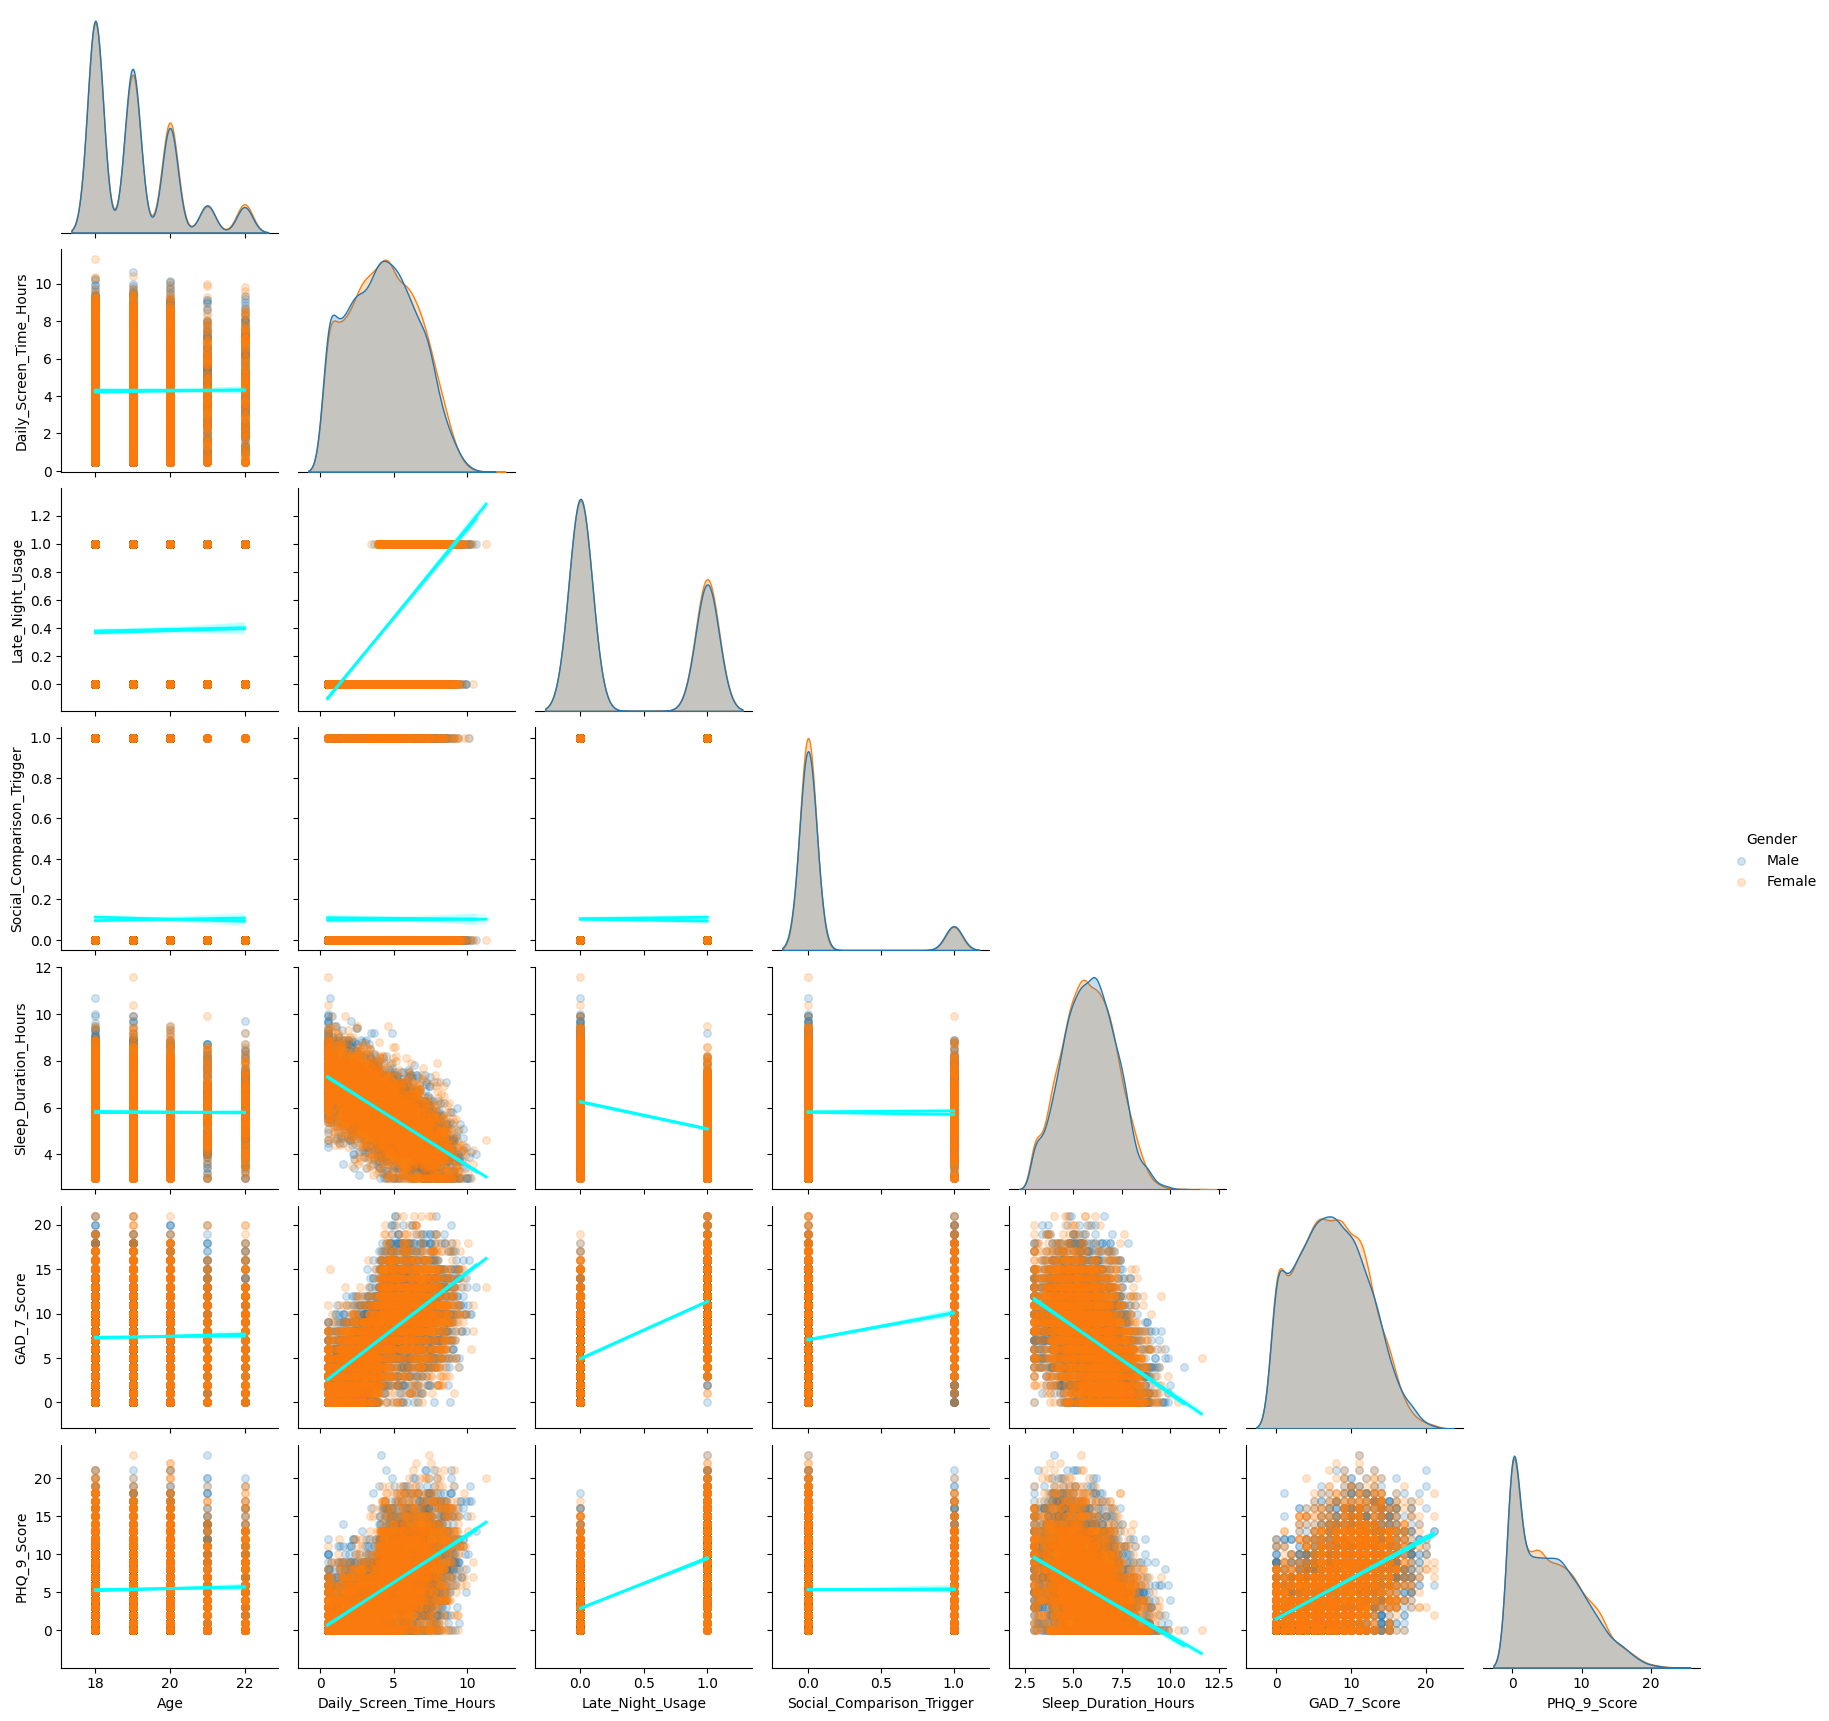

In [28]:
sns.pairplot(mental_health, hue = 'Gender', corner = True, kind='reg', plot_kws={
                          'line_kws': {'color': 'cyan', 'lw': 2}, # Regresinės linijos spalva ir storis
                          'scatter_kws': {'alpha': 0.2, 's': 30}  # Taškų permatomumas
                      })

We evaluate the impact of indicators on PHQ-9 score and GAD_7 score.  
PHQ_9 assesses depression: the higher the score, the more severe the degree of depression (0- no depression, 27- severe depression)  
GAD_7 assesses anxiety: the higher the score, the more severe the anxiety (0- no anxiety, 21- severe anxiety)  

The PHQ_9 score is influenced by the following indicators:  
The more screen_time_hours increases, the more the depression score increases  
The more sleep_duration_hours decreases, the more the depression score increases  
PHQ_9 and GAD_7 scores influence each other: the higher the anxiety score, the more the person experiences depression  

Age does not affect the score/depression level  
Social_comparison_trigger does not affect the score/depression level  

The GAD_7 score is influenced by the following indicators:  
The more screen_time_hours increases, the more the anxiety score increases  
The more sleep_duration_hours decreases, the more the anxiety score increases  
PHQ_9 and GAD_7 scores influence each other: the higher the depression score, the more anxiety a person experiences  

Age does not affect the score/anxiety level  
Social_comparison_trigger does not affect the score/anxiety level  

Gender distribution also does not make much difference: the impact of social media on depression and anxiety is the same for both women and men.  

To see the whole picture, I will convert categorical variables to numeric values ​​and create a correlation matrix.

In [29]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

def encode_all_categorical(df):
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        encoders[col] = le
    return df

mental_health = encode_all_categorical(mental_health) 

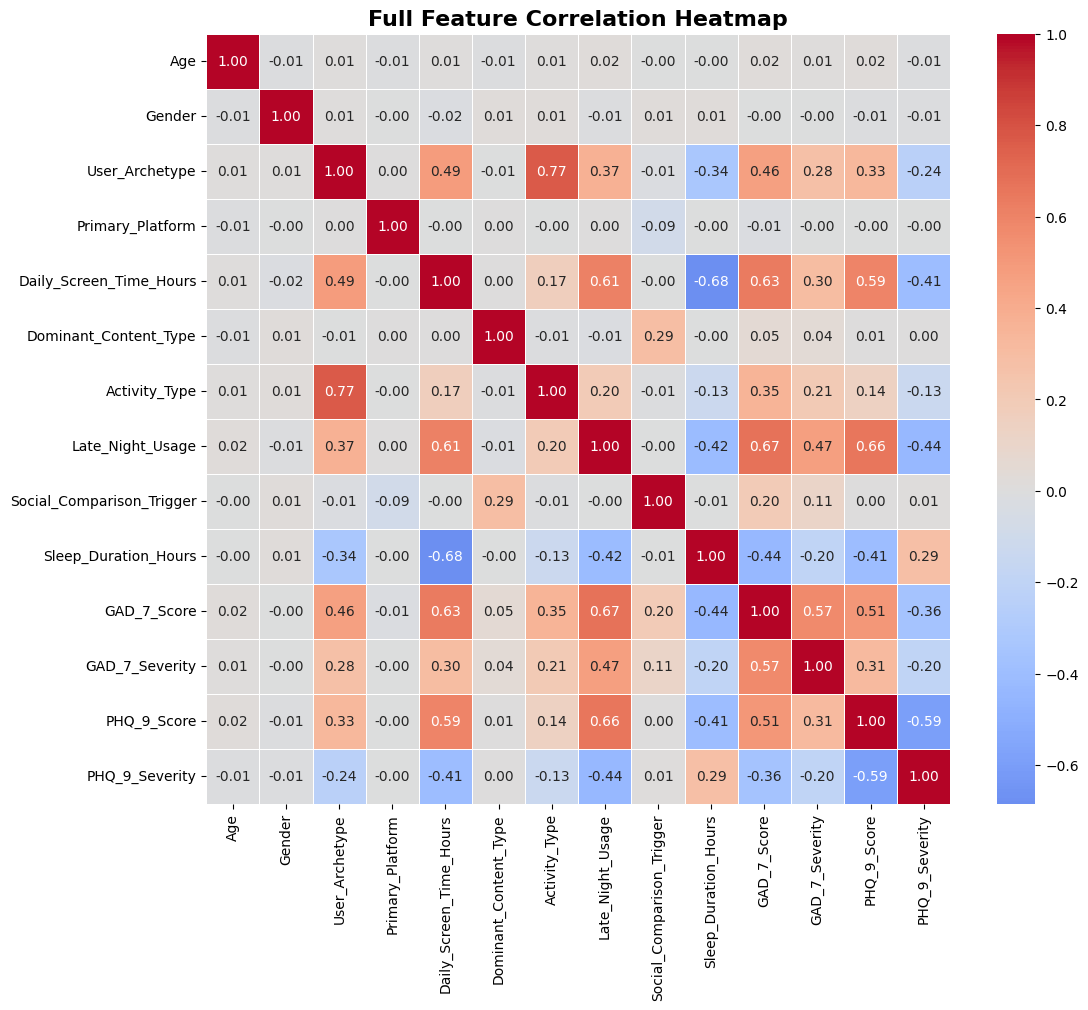

In [30]:
def plot_full_heatmap(df):
    corr = df.corr(numeric_only=True)

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, 
                annot=True,       
                fmt=".2f",        
                cmap='coolwarm',  
                linewidths=0.5, 
                center=0)         

    plt.title('Full Feature Correlation Heatmap', fontsize=16, fontweight='bold')
    plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_full_heatmap(mental_health)

The correlation matrix confirms two main things.  
First, the specific social media (TikTok, Instagram, etc.) and the type of content you watch do not affect your mental health scores (0.00).

The strongest links in this study are:

Daily Screen Time Hours: Shows a strong positive correlation with Late Night Usage (0.61), GAD-7 Score (0.63), and PHQ-9 Score (0.59). It is also strongly negatively correlated with Sleep Duration Hours (-0.68). People who spend more time on their screens usually use them late at night (0.61). This leads to much higher anxiety (0.63) and depression (0.59).

The Impact on Sleep: There is a very strong negative link between screen time and sleep (-0.68). This means as screen time goes up, sleep hours go down significantly.

GAD-7 Score (Anxiety): Most significantly correlates with Late Night Usage (0.67), Daily Screen Time (0.63), and PHQ-9 Score (0.51), while showing a negative correlation with Sleep Duration (-0.44).  
PHQ-9 Score (Depression): Primarily correlates with Late Night Usage (0.66), Daily Screen Time (0.59), and GAD-7 Score (0.51), with a negative correlation with Sleep Duration (-0.41).  
Anxiety & Depression (GAD-7 and PHQ-9): Both anxiety and depression are most strongly linked to using devices late at night (around 0.66). 

Next visualising these correlations between main features. 
To understand what causes anxiety and depression, I created four regression plots. These charts show how GAD-7 scores and PHQ-9 change based on sleep and screen time.

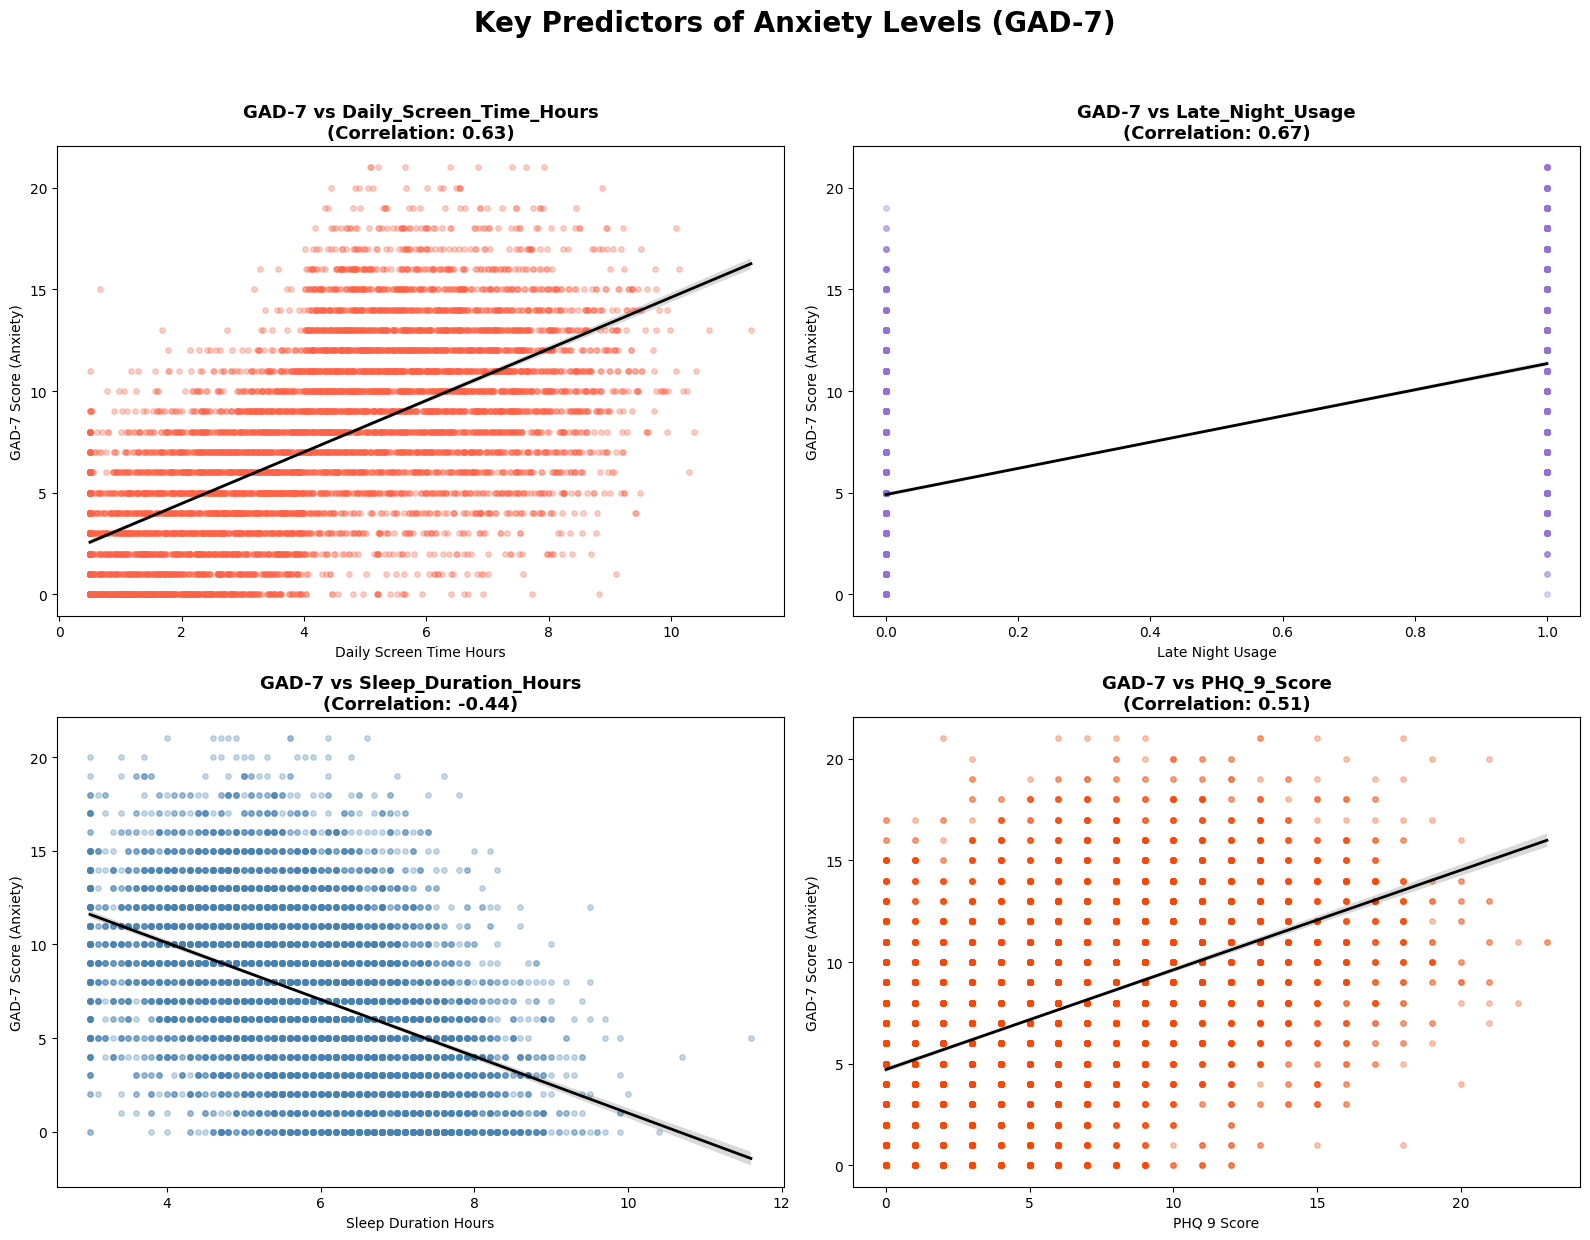

In [31]:
top_features = ['Daily_Screen_Time_Hours', 'Late_Night_Usage', 'Sleep_Duration_Hours', 'PHQ_9_Score']
corrs = [0.63, 0.67, -0.44, 0.51] 
colors = ['#FF6347', '#9370DB', '#4682B4', '#FF4500']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten() 

for i, col in enumerate(top_features):
    sns.regplot(data=mental_health, x=col, y='GAD_7_Score', ax=axes[i], 
                color=colors[i], scatter_kws={'alpha':0.3, 's':15},
                line_kws={'color':'black', 'lw':2})
    
    axes[i].set_title(f'GAD-7 vs {col}\n(Correlation: {corrs[i]})', 
                      fontsize=13, fontweight='bold')
    axes[i].set_ylabel('GAD-7 Score (Anxiety)')
    axes[i].set_xlabel(col.replace('_', ' ')) 

plt.suptitle('Key Predictors of Anxiety Levels (GAD-7)', fontsize=20, y=1.03, fontweight='bold')
plt.tight_layout()
plt.savefig('key_preditors_for_anxiety_GAD7.png', dpi=300, bbox_inches='tight')
plt.show()

What we see:  
Positive Slopes: As screen time and late-night use increase, anxiety scores also go up.  
Negative Slope: As sleep hours increase, anxiety scores go down.  
This confirms that sleep is the best natural 'medicine' for reducing anxiety in this group, while late-night scrolling is the biggest risk factor.
Anxiety GAD-7 and Depression PHQ-9 are connected.

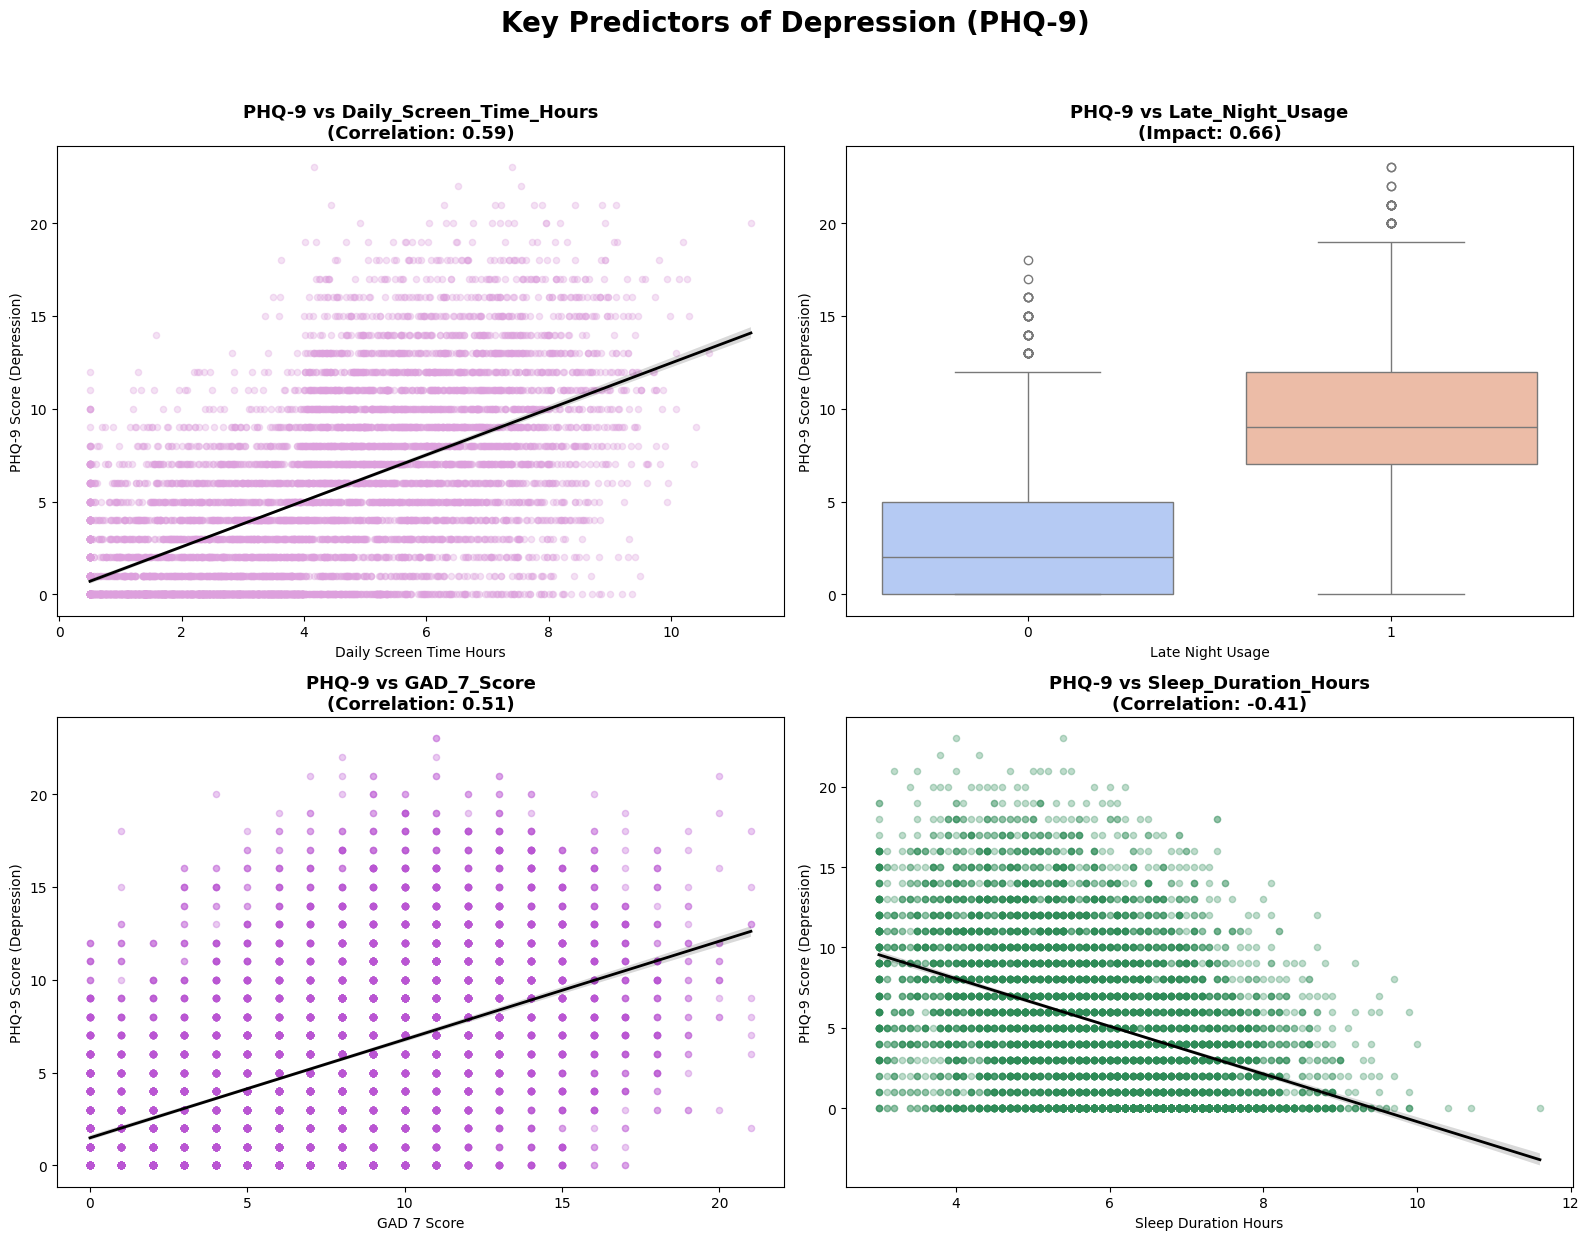

In [32]:

features = ['Daily_Screen_Time_Hours', 'Late_Night_Usage', 'GAD_7_Score', 'Sleep_Duration_Hours']
correlations = [0.59, 0.66, 0.51, -0.41]
colors = ['plum', 'royalblue', 'mediumorchid', 'seagreen']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    if col == 'Late_Night_Usage':
        sns.boxplot(data=mental_health, x=col, y='PHQ_9_Score', ax=axes[i], 
                    hue=col, palette='coolwarm', legend=False)
        axes[i].set_title(f'PHQ-9 vs {col}\n(Impact: {correlations[i]})', fontweight='bold', fontsize=13)
    
    else:
        sns.regplot(data=mental_health, x=col, y='PHQ_9_Score', ax=axes[i], 
                    color=colors[i], scatter_kws={'alpha':0.3, 's':20},
                    line_kws={'color':'black', 'lw':2})
        axes[i].set_title(f'PHQ-9 vs {col}\n(Correlation: {correlations[i]})', fontweight='bold', fontsize=13)

    axes[i].set_ylabel('PHQ-9 Score (Depression)')
    axes[i].set_xlabel(col.replace('_', ' '))

plt.suptitle('Key Predictors of Depression (PHQ-9)', fontsize=20, y=1.03, fontweight='bold')
plt.tight_layout()
plt.savefig('key_preditors_for_depression_PHQ9.png', dpi=300, bbox_inches='tight')
plt.show()

This four-chart dashboard explains the 'Why' behind depression scores. It connects screen habits, sleep, and anxiety.

Digital Habit Impact (Top Row):

Screen Time (0.59): The first graph shows a clear upward trend. As people spend more hours on their devices, their PHQ-9 (Depression) scores climb. It’s a very steady, linear relationship.

Late Night Usage (0.66 - Highest Impact): This is the most important finding. The boxplot shows that people who use devices late at night (Group 1) have much higher depression scores than those who don't (Group 0). The 'Late Night' group's median is nearly 10, while the other is close to 2.

The Biological and Psychological Link (Bottom Row):

Anxiety Link (0.51): There is a strong connection between anxiety (GAD-7) and depression. When one score is high, the other usually follows, showing how these issues often travel together.

The Sleep Protective Factor (-0.41): This graph shows a 'downward' slope. More sleep hours are linked to lower depression scores. This proves that sleep acts as a natural defense against mental health struggles.

The data proves that when you use your phone is more dangerous than how much you use it. Using devices late at night has the strongest link to high depression scores (0.66), likely because it effects sleep quality.

Further I will use code to perform a 'Triple Threat' analysis. It visualizes how Daily Screen Time acts as the primary driver for three critical health outcomes simultaneously: Sleep, Anxiety, and Depression."

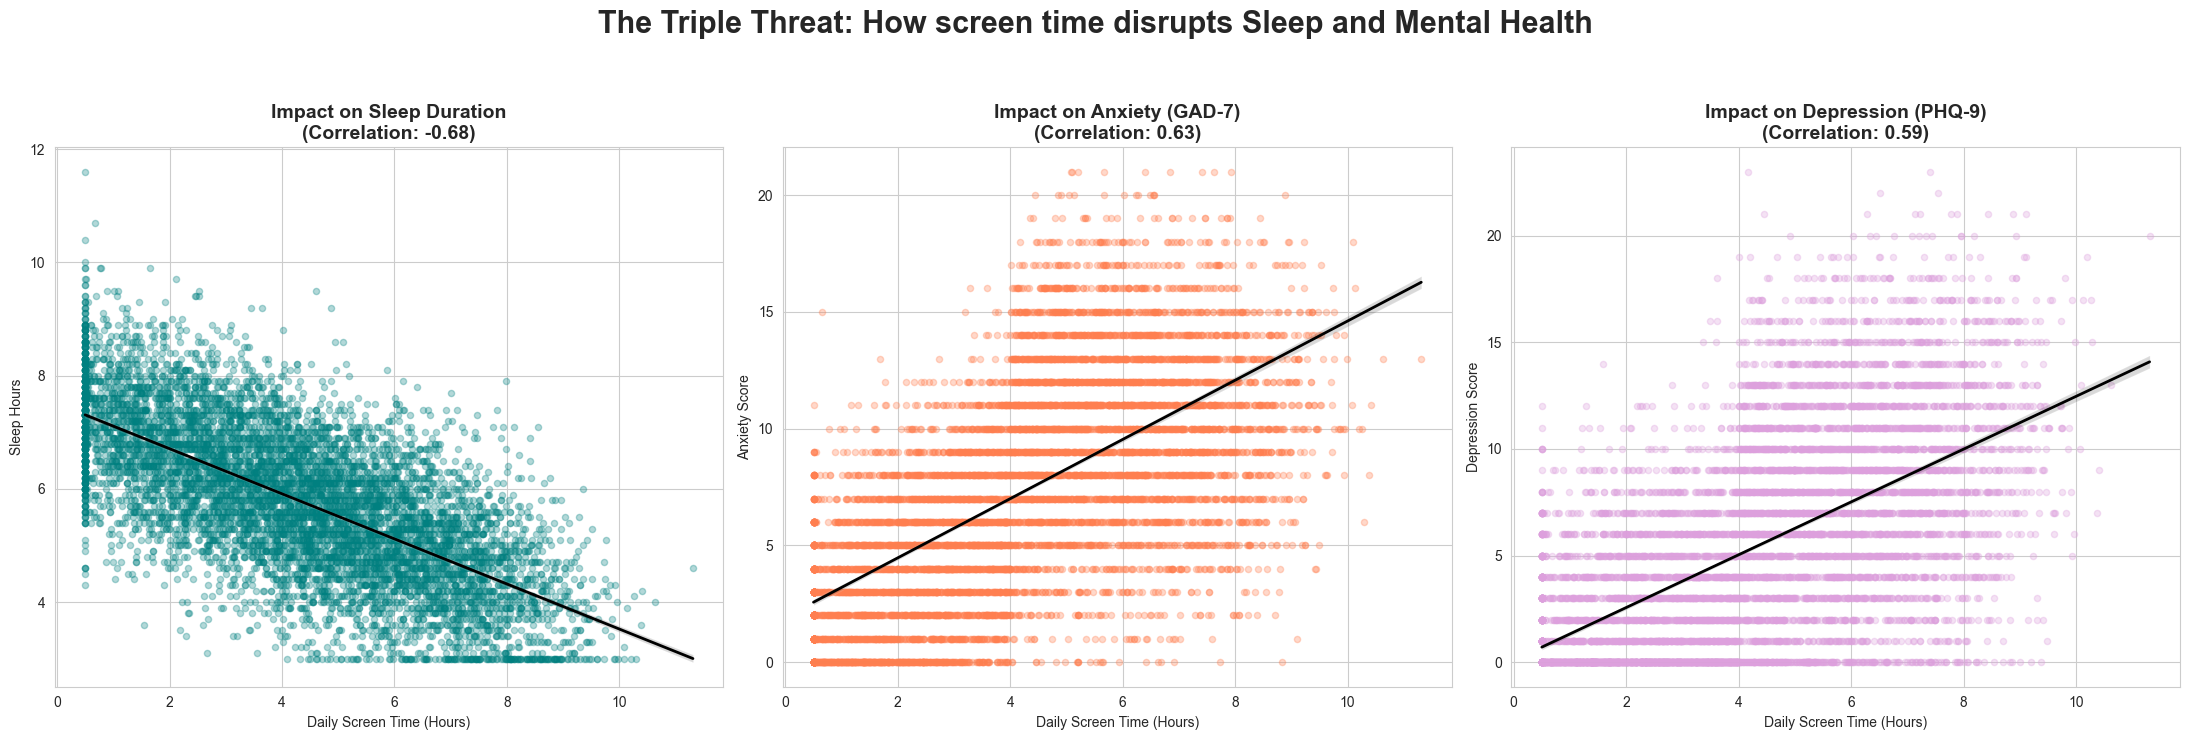

In [33]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# 1. Visualization: Screen Time vs. Sleep Duration
sns.regplot(data=mental_health, x='Daily_Screen_Time_Hours', y='Sleep_Duration_Hours', 
            ax=axes[0], color='teal', scatter_kws={'alpha':0.3, 's':20},
            line_kws={'color':'black', 'lw':2})
axes[0].set_title('Impact on Sleep Duration\n(Correlation: -0.68)', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Sleep Hours')
axes[0].set_xlabel('Daily Screen Time (Hours)')

# 2. Visualization: Screen Time vs. Anxiety (GAD-7)
sns.regplot(data=mental_health, x='Daily_Screen_Time_Hours', y='GAD_7_Score', 
            ax=axes[1], color='coral', scatter_kws={'alpha':0.3, 's':20},
            line_kws={'color':'black', 'lw':2})
axes[1].set_title('Impact on Anxiety (GAD-7)\n(Correlation: 0.63)', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Anxiety Score')
axes[1].set_xlabel('Daily Screen Time (Hours)')

# 3. Visualization: Screen Time vs. Depression (PHQ-9)
sns.regplot(data=mental_health, x='Daily_Screen_Time_Hours', y='PHQ_9_Score', 
            ax=axes[2], color='plum', scatter_kws={'alpha':0.3, 's':20},
            line_kws={'color':'black', 'lw':2})
axes[2].set_title('Impact on Depression (PHQ-9)\n(Correlation: 0.59)', fontweight='bold', fontsize=14)
axes[2].set_ylabel('Depression Score')
axes[2].set_xlabel('Daily Screen Time (Hours)')

plt.suptitle('The Triple Threat: How screen time disrupts Sleep and Mental Health', 
             fontsize=22, y=1.05, fontweight='bold')

plt.tight_layout()
plt.savefig('Screen_Time_Impact.png', dpi=300, bbox_inches='tight')
plt.show()

By using this visualization, I am proving that we cannot talk about mental health without talking about sleep. The code highlights that excessive screen time steals sleep, and this lack of sleep is likely what causes the spikes in anxiety and depression scores.  

This analysis proves that as Daily Screen Time increases, we see a significant decline in sleep quality and mental well-being. The correlation of -0.68 with sleep is particularly alarming, suggesting that screen time is the primary factor displacing healthy rest.

## Conclusions

The data analysis reveals a clear and statistically significant link between social media habits and mental health outcomes. The primary findings are:

**The "When" Matters More Than the "What"**: Social media platform choice (e.g., TikTok vs. LinkedIn) and content type (e.g., Comedy vs. News) showed **zero correlation (0.00)** with depression or anxiety scores.

**Screen Time**: Excessive daily screen time acts as a catalyst for mental health decline. It is strongly linked to **Anxiety (0.63)** and **Depression (0.59)**.

**Sleep Displacement**: The strongest relationship in the study is the negative correlation between screen time and sleep duration **(-0.68)**. This proves that screens directly "steal" time from biological recovery.

**Late-Night Usage as a Risk Factor**: Using devices late at night has the highest impact on **PHQ-9 (0.66)** and **GAD-7 (0.67)** scores. This habit is the most reliable predictor of high mental health distress in this dataset.


## Recommendations

Based on these evidence-based findings, the following public health and individual interventions are recommended:

Since **Late Night Usage** is the strongest predictor of anxiety and depression, individuals should implement a "Digital Sunset"—stopping all screen use at least **60 to 90 minutes before bed**. This allows for natural melatonin production and protects the sleep window.

Users should be educated that the danger of social media isn't necessarily the content they watch, but the **activities it replaces**. For every hour of social media used, users should ensure it does not reduce their sleep below the recommended 7–9 hour threshold.

Because **Daily Screen Time** correlates so strongly with **GAD-7 (0.63)**, setting hard limits on total daily usage (e.g., maximum 3–4 hours) could serve as a primary preventative measure against developing moderate-to-severe anxiety symptoms.